# BRFSS 2024 Obesity Risk Analysis


Identifying behavioral and health risk factors associated with obesity using the Behavioral Risk Factor Surveillance System (BRFSS) 2024 dataset.


## Team 2

| Name     | GitHub ID  ||
|----------|-------------|-------------------------------------------|
| Lulu Massasi     |  (GitHub: @lr-2026) |
| Akhil Haris Arakkal   |  (GitHub: @AkhilHaris111)|
| Diego Quispe Vilcahuaman     |  (GitHub: @dlqui) |


## Project Overview

## Project Objective

The goal of this project is to identify risk factors and population groups associated with obesity using data from the BRFSS 2024 survey.  

We aim to build interpretable predictive models that help identify individuals at higher risk of obesity based on health conditions, behaviors, and demographics.  

**Obesity is defined as:**  
BMI ≥ 30

### What is new about our approach?

Rather than focusing only on prediction accuracy, our approach emphasizes:  

- Interpretable predictors  
- Identification of risk clusters  
- Public health insights  

This allows the results to be more useful for policy and health intervention design.

### Who cares?

The primary stakeholders are:  

- Public health researchers  
- CDC analysts  
- Health policy planners  

If successful, the project could help identify behavioral and demographic risk factors that contribute to obesity, supporting targeted health interventions.

---

## Data

### Data Source

The dataset used in this project comes from the **Behavioral Risk Factor Surveillance System (BRFSS)**.  

Source: [CDC BRFSS](https://www.cdc.gov/brfss)  

BRFSS is conducted annually by the Centers for Disease Control and Prevention (CDC) and collects information about:  

- Health conditions  
- Lifestyle behaviors  
- Preventive health practices  
- Demographic characteristics  

The dataset is widely used in public health research, making it a credible and well-documented source.

### Dataset Description

- **Original dataset format:** .XPT  
- **Size:** ~1.01 GB  

To meet GitHub size limitations, the dataset was:  

- Converted to Parquet format  
- Split into smaller files  

The final dataset contains:  

- 457,669 observations  
- Hundreds of survey variables  

---

## Exploratory Data Analysis

We explored the dataset to understand:  

- Variable distributions  
- Correlations between health variables  
- Potential patterns related to obesity  

The following visualizations summarize key patterns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_parquet("brfss_2024_qusipe_clean.parquet")
df.head()


,ASTHMA3,ASTHNOW,BMI,BMI_raw,CASTHDX2,CASTHNO2,_ASTHMS1,_BMI5CAT,_CASTHM1,_DENVST3,...,_MRACE1,_RACE,_RACEG21,_RACEGR3,_RACEPRV,Smoker,_SMOKER3,obesity,outlier_flag,risk_cluster
0,0.0,0.0,-0.661290,-0.661290,0.0,0.0,0.0,-0.5,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,No,4.0,0,False,1
1,0.0,0.0,-0.212366,-0.212366,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,No,3.0,1,True,2
2,0.0,0.0,-0.655914,-0.655914,0.0,0.0,0.0,-0.5,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,Yes,1.0,0,False,1
3,0.0,0.0,-0.311828,-0.311828,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,No,4.0,0,False,2
4,0.0,0.0,-1.026882,-1.026882,0.0,0.0,0.0,-0.5,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,No,4.0,0,False,1


## Distribution of Health Variables

**First** we examined the distribution of health-related variables to understand their shape and detect potential outliers or skewed distributions.

## Correlation Analysis

We also examined correlations between health variables to identify potential relationships associated with obesity risk.



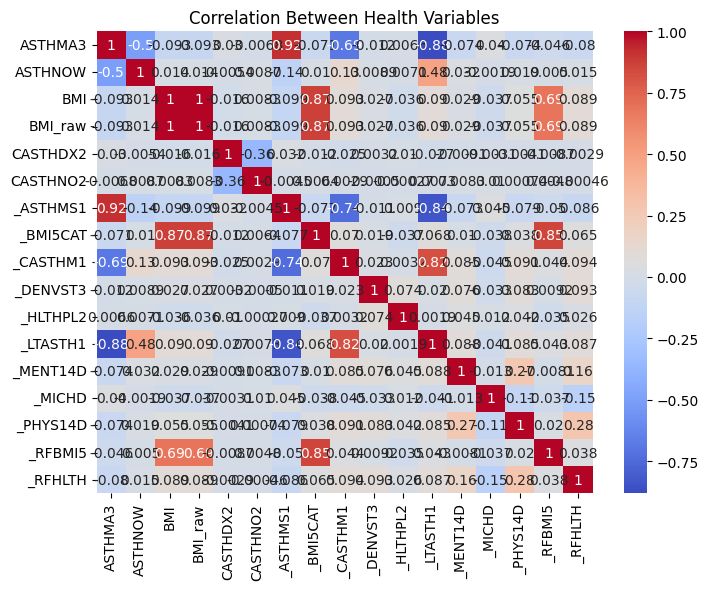

In [2]:
health_patterns = [
    'BMI', 'ASTH', 'MICHD', 'RFHLTH', 'PHYS14D',
    'MENT14D', 'HLTHPL2', 'DENVST3', 'DIABETES',
    'HYPERTENSION', 'CHOLESTEROL'
]
health_vars = [c for c in df.columns if any(p.lower() in c.lower() for p in health_patterns)]
plt.figure(figsize=(8,6))
sns.heatmap(df[health_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Health Variables")
plt.show()



## Dimensionality Reduction (PCA)

To explore underlying health patterns, we applied Principal Component Analysis (PCA).

PCA helps identify latent factors that explain variance in health variables.


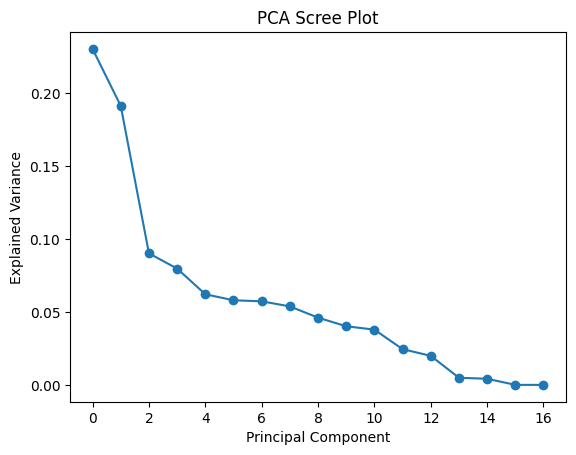

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[health_vars].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_

plt.plot(explained, marker='o')
plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.show()


## Preprocessing

### Data Cleaning


Before modeling, several preprocessing steps were required to ensure data quality and integrity:  

- Handling missing values  
- Encoding categorical variables  
- Removing variables that could cause data leakage  

### Missing Value Handling

- **Numeric variables:** Median imputation was applied because it is robust to skewed distributions.  
- **Categorical variables:** Mode imputation was used to fill missing values with the most frequent category.


In [4]:
df = df.fillna(df.median(numeric_only=True))

## Encoding
Categorical variables were encoded using Ordinal Encoding for ordered categories.

Binary variables were converted into 0/1 values.


In [5]:

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

## Baseline Model

As an initial baseline, we trained a Random Forest classifier to predict obesity.

This allows us to obtain an early estimate of model performance.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler


df = pd.read_parquet('brfss_2024_qusipe_clean.parquet')


health_patterns = ['BMI', 'ASTH', 'MICHD', 'RFHLTH', 'PHYS14D', 'MENT14D', 'HLTHPL2', 'DENVST3', 'DIABETES', 'HYPERTENSION', 'CHOLESTEROL']
health_vars = [c for c in df.columns if any(p.lower() in c.lower() for p in health_patterns)]
print("Health variables for EDA:", health_vars)
# Load PCA object
pca = joblib.load('pca_health_vars.joblib')
print("PCA object loaded.")

# Transform new data using the saved PCA
df_pca = pca.transform(df[health_vars])
print("PCA transformed shape:", df_pca.shape)
X = df_pca
y = df['obesity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC Score:", roc_auc)

Health variables for EDA: ['ASTHMA3', 'ASTHNOW', 'BMI', 'BMI_raw', 'CASTHDX2', 'CASTHNO2', '_ASTHMS1', '_BMI5CAT', '_CASTHM1', '_DENVST3', '_HLTHPL2', '_LTASTH1', '_MENT14D', '_MICHD', '_PHYS14D', '_RFBMI5', '_RFHLTH']
PCA object loaded.
PCA transformed shape: (409415, 5)
Confusion Matrix:
[[73721     0]
 [ 8162     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     73721
           1       0.00      0.00      0.00      8162

    accuracy                           0.90     81883
   macro avg       0.45      0.50      0.47     81883
weighted avg       0.81      0.90      0.85     81883


ROC-AUC Score: 0.5009415104367696


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Problems & Challenges

Several challenges were encountered during the project:

### High Dimensionality
The BRFSS dataset contains hundreds of variables, many of which are irrelevant to obesity prediction. Careful feature selection was required to focus on the most informative variables.

### Sparse Data
Many variables contain large numbers of missing values due to conditional survey questions. This leads to sparse columns, which can introduce bias if not handled properly.

### Dataset Size
The original dataset was over 10GB, requiring conversion to Parquet format and compression to store it efficiently in the repository.

---

## Next Steps

The next phase of the project will focus on improving predictive models and identifying interpretable predictors.  

**Planned tasks include:**  

- **Training additional models:**  
  - Logistic Regression  
  - Random Forest (different hyperparameters)
  - Gradient Boosting  

- **Evaluating models using metrics:**  
  - Accuracy  
  - Precision  
  - Recall  
  - F1-score  
  - ROC-AUC  

- Identifying important predictors of obesity risk  
- Performing additional clustering analysis to identify high-risk subgroups

---

## Estimated Timeline

| Task                    | Estimated Completion |
|-------------------------|--------------------|
| Model training           | Next 1–2 weeks     |
| Model evaluation         | Next checkpoint    |
| Final report preparation | End of project     |